# exp-nb-ratio-ovr-01 — class-conditional NB-ratio OVR LR
각 class 대 나머지의 fold-train log-count ratio를 계산해 class별 sparse 입력을 만들고 binary OVR LR을 학습한다. event core와 signature 두 표현, 단독·고정 0.25 blend만 비교한다.


row-local mutation cache: 100%|██████████| 4384/4384 [00:12<00:00, 354.25it/s]
nb-ratio-ovr | seed 42: 100%|██████████| 5/5 [00:49<00:00,  9.89s/fold]


[
  {
    "experiment_id":"exp-nb-ratio-ovr-01",
    "variant":"event_core",
    "model":"lr",
    "seed":42,
    "oof_macro_f1":0.4825927952,
    "delta_vs_variant_lr":0.0,
    "feature_count_mean":8171.2,
    "leakage_check":true,
    "nan_as_mutation_count":0,
    "convergence_warning_count":0,
    "smoothing":1.0,
    "blend_weight_nb":0.25
  },
  {
    "experiment_id":"exp-nb-ratio-ovr-01",
    "variant":"event_core",
    "model":"nb_ratio_ovr",
    "seed":42,
    "oof_macro_f1":0.4621430048,
    "delta_vs_variant_lr":-0.0204497903,
    "feature_count_mean":8171.2,
    "leakage_check":true,
    "nan_as_mutation_count":0,
    "convergence_warning_count":0,
    "smoothing":1.0,
    "blend_weight_nb":0.25
  },
  {
    "experiment_id":"exp-nb-ratio-ovr-01",
    "variant":"event_core",
    "model":"lr075_nb025",
    "seed":42,
    "oof_macro_f1":0.4937992052,
    "delta_vs_variant_lr":0.01120641,
    "feature_count_mean":8171.2,
    "leakage_check":true,
    "nan_as_mutation_count":0,


,experiment_id,variant,model,seed,oof_macro_f1,delta_vs_variant_lr,feature_count_mean,leakage_check,nan_as_mutation_count,convergence_warning_count,smoothing,blend_weight_nb
5,exp-nb-ratio-ovr-01,event_core_signature,lr075_nb025,42,0.497118,0.014525,35179.0,True,0,0,1.0,0.25
2,exp-nb-ratio-ovr-01,event_core,lr075_nb025,42,0.493799,0.011206,8171.2,True,0,0,1.0,0.25
0,exp-nb-ratio-ovr-01,event_core,lr,42,0.482593,0.000000,8171.2,True,0,0,1.0,0.25
3,exp-nb-ratio-ovr-01,event_core_signature,lr,42,0.482593,0.000000,35179.0,True,0,0,1.0,0.25
1,exp-nb-ratio-ovr-01,event_core,nb_ratio_ovr,42,0.462143,-0.020450,8171.2,True,0,0,1.0,0.25
4,exp-nb-ratio-ovr-01,event_core_signature,nb_ratio_ovr,42,0.439959,-0.042634,35179.0,True,0,0,1.0,0.25


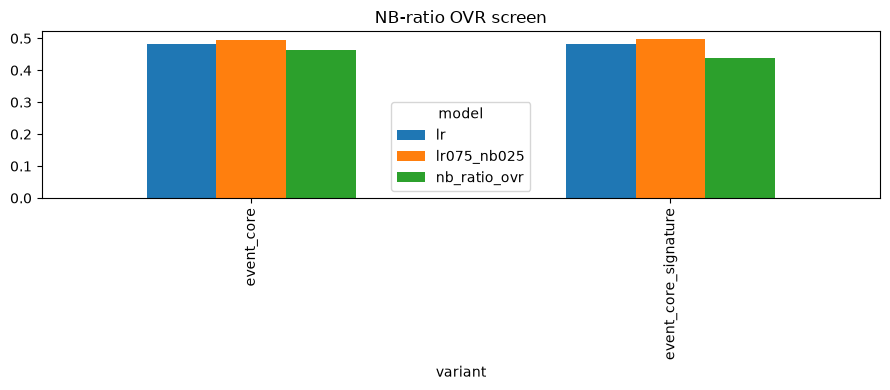

In [1]:
from pathlib import Path
import subprocess,sys,pandas as pd, matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'experiments/gs/notebooks/exp_model/common/exp_nb_ratio_ovr_runner.py').exists())
RUNNER=ROOT/'experiments/gs/notebooks/exp_model/common/exp_nb_ratio_ovr_runner.py'; RESULT=RUNNER.parent.parent/'result'; RUN_ID='exp-nb-ratio-ovr-01'; SEED=42; RUN=True
if RUN: subprocess.run([sys.executable,str(RUNNER),'--seed',str(SEED),'--run-id',RUN_ID],check=True)
s=pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_summary.csv'); assert s.leakage_check.all() and s.nan_as_mutation_count.eq(0).all(); display(s.sort_values('oof_macro_f1',ascending=False))
s.pivot(index='variant',columns='model',values='oof_macro_f1').plot.bar(figsize=(9,4),title='NB-ratio OVR screen'); plt.tight_layout(); plt.show()
